---
title: "Evaluating an existing site combination"
image: image.png
toc: true
execute: 
  enabled: true
---

Lokigi can also help you to evaluate your current setup, helping you to provide data that supports a case for a wider programme of re-evaluation. 

It's also useful to be able to provide a baseline for comparison with any solutions created. 

In [1]:
from lokigi.site import SiteProblem

problem_public_transport_extended = SiteProblem()

problem_public_transport_extended.add_sites(
    "../../../sample_data/devon_mius.geojson",
    candidate_id_col="Facility_Name"
    )

problem_public_transport_extended.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3c_interactive_plots_travel/raw/main/h6_3c_interactive_plots_travel/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

problem_public_transport_extended.add_travel_matrix(
    travel_matrix_df="../../../sample_data/devon_miu_travel_matrix_public_transport_extended.csv",
    source_col="from_id",
    unit="minutes",
    )


In this instance, we have 15 sites. 

In [2]:
problem_public_transport_extended.show_sites()

,canonical_site_index,Facility_Name,Latitude,Longitude,geometry
0,0,North Devon District Hospital,51.09217,-4.05043,POINT (256506.101 134540.134)
1,1,Honiton Hospital,50.79492,-3.18659,POINT (316466.043 100155.33)
2,2,Tiverton & District Hospital,50.90933,-3.49308,POINT (295122.857 113268.884)
3,3,Exmouth Minor Injury Unit,50.62083,-3.40198,POINT (300919.29 81063.23)
4,4,Victoria Hospital (Sidmouth),50.68161,-3.23966,POINT (312514.661 87617.001)
5,5,Newton Abbot Community Hospital,50.53926,-3.61224,POINT (285848.833 72295.946)
6,6,Totnes Community Hospital,50.43283,-3.68406,POINT (280491.309 60575.271)
7,7,NHS Walk in Centre (Exeter),50.72658,-3.52521,POINT (292444.533 92994.08)
8,8,Tavistock Hospital,50.54708,-4.15376,POINT (247503.629 74139.474)
9,9,South Hams Hospital (Kingsbridge),50.28929,-3.78143,POINT (273194.03 44777.085)


So when we solve, we simply solve for p=15.

In this instance, we're passing in an optional 'threshold_for_coverage', which will flag if any regions have a travel time of more than 60 minutes from their nearest MIU.

Since every one of these 15 sites is already open, this isn't really a "solve" in the optimisation sense -- we already know which sites we want evaluated. `evaluate_baseline()` does exactly that: it evaluates one named set of sites directly, without brute-forcing through every other combination of 15 sites (of which there's only one anyway). It returns the same kind of `SiteSolutionSet` that `solve()` does, so everything below -- plotting, equity checks -- works identically either way.

In [3]:
solution = problem_public_transport_extended.evaluate_baseline(
    site_names=problem_public_transport_extended.show_sites()["Facility_Name"].tolist(),
    threshold_for_coverage=60, # OPTIONAL
    )

C:\lokigi\lokigi\site.py:570: UserWarning: No demand data was provided. Demand from all regions has been assumed to be equal. If you wish to override this, run .add_demand() to add your demand dataframe before calling evaluate_baseline() again.
  warn(


In [4]:
solution.show_solutions()

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,total_cost,proportion_within_coverage_threshold,proportion_regions_within_coverage_threshold,...,gap_absolute_weighted,gap_relative_weighted,avg_lower_third_bins,avg_middle_third_bins,avg_upper_third_bins,inter_tertile_ratio,gap_absolute_description,gap_relative_description,inter_tertile_description,problem_df
0,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",60,56.03,56.03,96.4,262.0,NaN,0.63,0.63,...,None,None,None,None,None,None,N/A (No equity data),N/A (No equity data),N/A (No equity data),from_id North Devon District Hos...


C:\lokigi\lokigi\mixins\site_solution_plots.py:605: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ].plot(


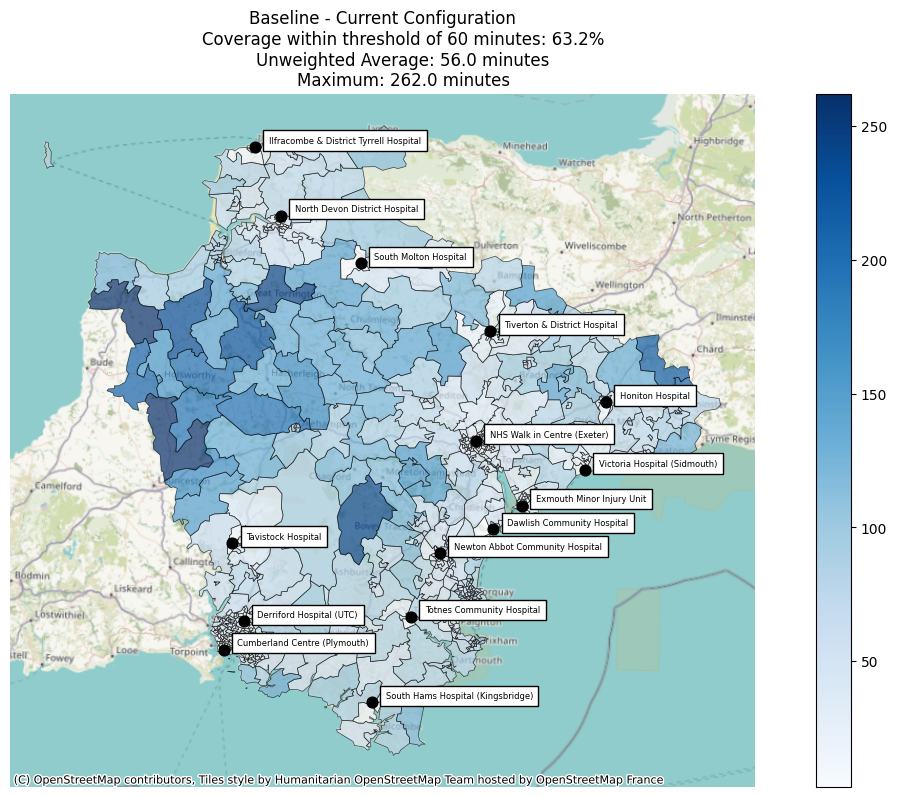

In [5]:
solution.plot_best_combination(
        title = """Baseline - Current Configuration
        Coverage within threshold of {solution['coverage_threshold'].values[0]} minutes: {solution['proportion_within_coverage_threshold'].values[0]:.1%}
        Unweighted Average: {solution['unweighted_average'].values[0]:.1f} minutes
        Maximum: {solution['max'].values[0]:.1f} minutes""",
        height=16,
        width=9,
        annotation_size=6
        );


C:\lokigi\lokigi\mixins\site_solution_plots.py:605: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ].plot(


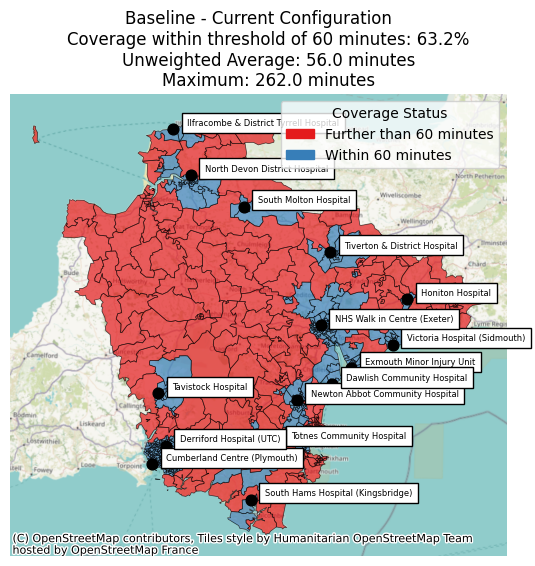

In [6]:
solution.plot_best_combination(
    plot_regions_not_meeting_threshold=True,
    title = """Baseline - Current Configuration
    Coverage within threshold of {solution['coverage_threshold'].values[0]} minutes: {solution['proportion_within_coverage_threshold'].values[0]:.1%}
    Unweighted Average: {solution['unweighted_average'].values[0]:.1f} minutes
    Maximum: {solution['max'].values[0]:.1f} minutes"""
    );

C:\lokigi\lokigi\mixins\site_solution_plots.py:605: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ].plot(


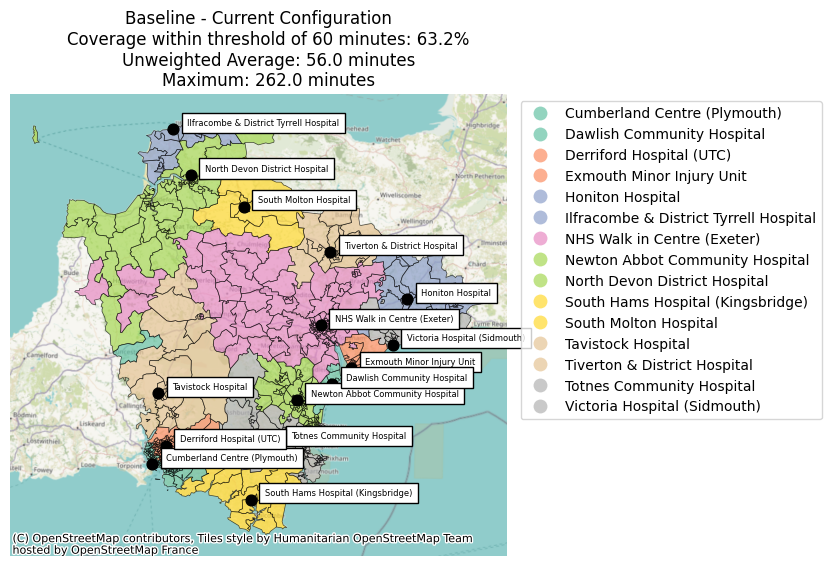

In [7]:
solution.plot_best_combination(
    plot_site_allocation=True,
    legend_bbox_to_anchor=(1.65, 1),
    title = """Baseline - Current Configuration
    Coverage within threshold of {solution['coverage_threshold'].values[0]} minutes: {solution['proportion_within_coverage_threshold'].values[0]:.1%}
    Unweighted Average: {solution['unweighted_average'].values[0]:.1f} minutes
    Maximum: {solution['max'].values[0]:.1f} minutes"""
    );

We might also want to explore the solution equity. 

In [8]:
problem_public_transport_extended.add_equity_data(
    "../../../sample_data/Index_of_Multiple_Deprivation_(Dec_2015)_Lookup_in_England.csv",
    equity_col="IMD15",
    common_col="LSOA11NM",
    label="Indices of Multiple Deprivation",
    continuous_measure=True,
    reverse=False
    )

<Axes: >

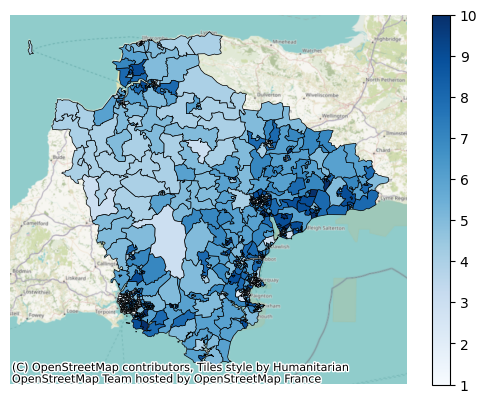

In [9]:
problem_public_transport_extended.plot_region_geometry_layer(
    plot_equity=True,
    plot_region_of_interest_only=True
    )

Let's re-evaluate the baseline, overwriting our previous object. 

In [10]:
solution = problem_public_transport_extended.evaluate_baseline(
    site_names=problem_public_transport_extended.show_sites()["Facility_Name"].tolist(),
    threshold_for_coverage=60, # OPTIONAL
    )

In [11]:
solution.check_solution_equity(return_plot=True)

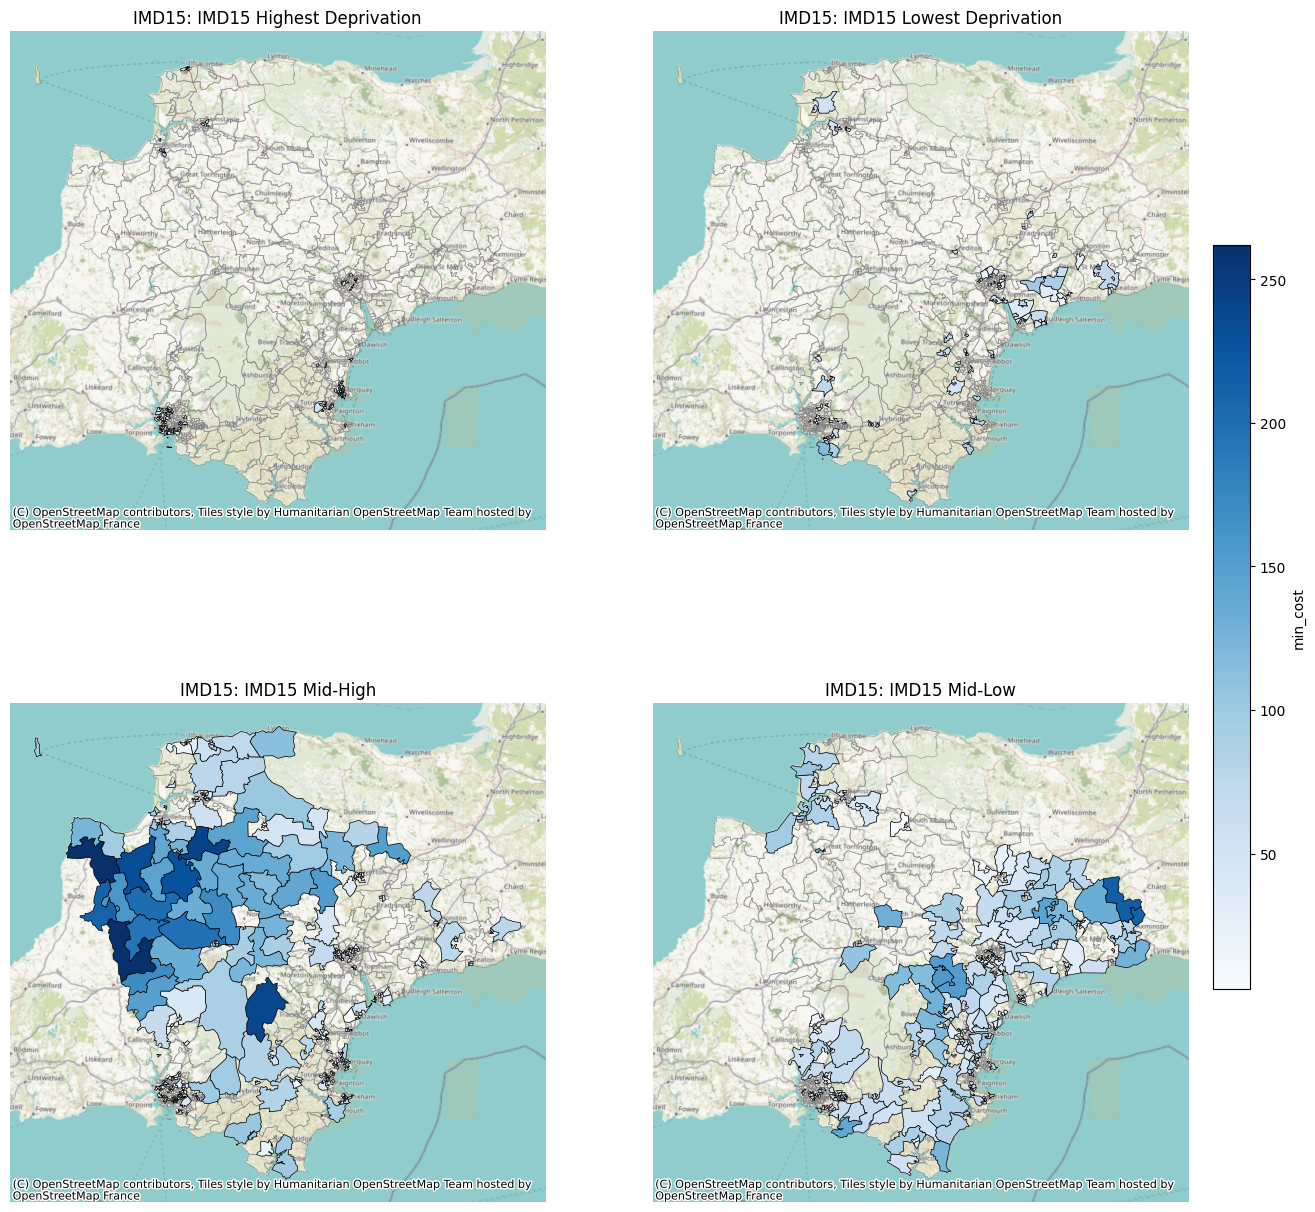

In [12]:
groupings = {
    "IMD15 Highest Deprivation": [1, 2],
    "IMD15 Lowest Deprivation": [9, 10],
    "IMD15 Mid-High": [3, 4, 5],
    "IMD15 Mid-Low": [6, 7, 8],
}

solution.plot_combination_by_equity(figsize_multiplier=8, groupings=groupings, ncols=2);

Once we have a baseline, we can start using our [comparison tools](../comparing_solutions/index.ipynb), or measure how many people's journeys would actually change if we opened a new site, in [Population Impact vs Baseline](../population_impact/index.ipynb).